In [43]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [44]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

In [45]:
import seaborn as sns 

df = sns.load_dataset("penguins") 
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# X/y split을 위해 먼저 수행할것
1. 결측치 처리
2. 이상치 확인
3. feature 선별
 - 수치형 변수와 범주형 변수를 나눠서 상관관계 분석
 - 특징간의 관계나 특징-타겟간의 관계

In [46]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [47]:
df.dropna(subset=['sex'], inplace=True)

In [48]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [55]:
df['species_target'] = df['species'].map({
    'Adelie' : 0,
    'Gentoo' : 1,
    'Chinstrap' : 2
})

In [56]:
#범주형 변수와 수치형 변수로 분리

categorical_cols = df.select_dtypes(exclude=['number']).columns
print(categorical_cols)

numeric_cols = df.select_dtypes(include=['number']).columns
print(numeric_cols)

Index(['species', 'island', 'sex'], dtype='object')
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
       'species_target'],
      dtype='object')


In [57]:
# 범주형 타깃과 수치형 특징간의 관계
for col in numeric_cols:
    print(f"--- {col} ---")
    print(df.groupby('species')[col].mean())
    print()

--- bill_length_mm ---
species
Adelie       38.823973
Chinstrap    48.833824
Gentoo       47.568067
Name: bill_length_mm, dtype: float64

--- bill_depth_mm ---
species
Adelie       18.347260
Chinstrap    18.420588
Gentoo       14.996639
Name: bill_depth_mm, dtype: float64

--- flipper_length_mm ---
species
Adelie       190.102740
Chinstrap    195.823529
Gentoo       217.235294
Name: flipper_length_mm, dtype: float64

--- body_mass_g ---
species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64

--- species_target ---
species
Adelie       0.0
Chinstrap    2.0
Gentoo       1.0
Name: species_target, dtype: float64



In [58]:
# 수치형 타깃과 수치형 특징
for col in numeric_cols:
    corr = df[col].corr(df['species_target'])
    print(col, corr)

bill_length_mm 0.777472941112009
bill_depth_mm -0.1737893902588065
flipper_length_mm 0.3460612465526612
body_mass_g 0.19925919061850972
species_target 1.0


bill_length_mm = 0.777

- 가장 강한 양의 관계로 보입니다.
즉, 이 특성이 종을 구분하는 데 가장 도움이 될 가능성이 큽니다.

bill_depth_mm = -0.173

- 거의 상관이 없거나 매우 약한 음의 관계입니다.
- 종 분류에 큰 도움이 되지 않을 가능성이 높습니다.


flipper_length_mm = 0.346

- 약한~중간 정도의 양의 관계입니다.
- 도움이 될 수는 있지만, bill_length_mm보다는 덜 강합니다.


body_mass_g = 0.199

- 매우 약한 양의 관계입니다.
- 참고 정도로만 보는 것이 좋습니다.


species_target = 1.0

- 이 값은 자기 자신과의 상관관계라서 의미가 없습니다.
- 즉, 타깃과의 관계를 보는 값이 아닙니다.

In [62]:
#수치형 타깃 & 범주형 타깃 범주형 특징
for i in categorical_cols:
    print(df.groupby('species_target')[i].value_counts())

species_target  species  
0               Adelie       146
1               Gentoo       119
2               Chinstrap     68
Name: count, dtype: int64
species_target  island   
0               Dream         55
                Torgersen     47
                Biscoe        44
1               Biscoe       119
2               Dream         68
Name: count, dtype: int64
species_target  sex   
0               Female    73
                Male      73
1               Male      61
                Female    58
2               Female    34
                Male      34
Name: count, dtype: int64


# 지금까지의 상관관계 분석을 바탕으로 X,y split

In [63]:
y = df['species']
X = pd.get_dummies(df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "island"]],
                   columns=["island"])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y 
)

In [65]:
model = RandomForestClassifier(
    n_estimators=100, # decision tree개수
    max_depth=None, # 트리의 깊이 제한 X 통상 100부터 => overfitting(과대적합 위험이 증가 하이퍼파라미터 튜닝 시 조정
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred=model.predict(X_test)

In [67]:
accuracy = accuracy_score(y_test,y_pred)
print('random forest 정확도 : ',round(accuracy, 3))

random forest 정확도 :  1.0


In [69]:
print(classification_report(
    y_test,
    y_pred,
    target_names = df['species'].unique()
))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [70]:
importance = pd.DataFrame({
    "feature" : X.columns,
    "importance" : model.feature_importances_})
# scikit_learn 에서 학습 후 생기는 값의이름끝에 _ 붙이는 경향이 존재함

importance = importance.sort_values(
    by = "importance",
    ascending = True
)

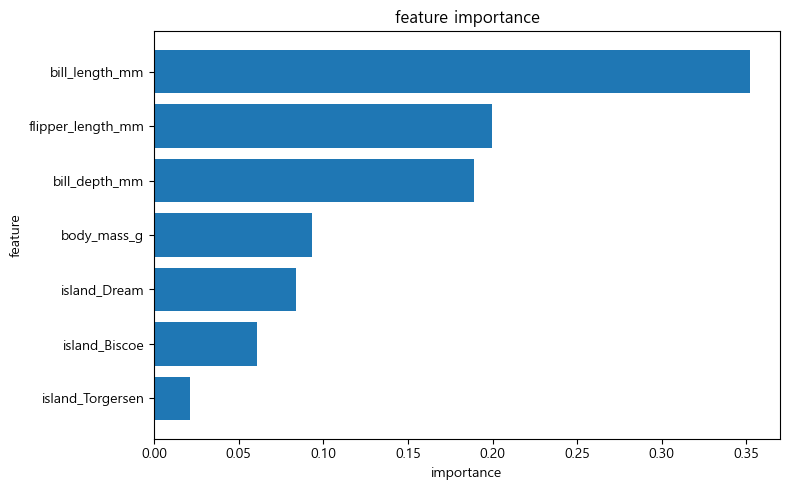

In [71]:
plt.figure(figsize = (8,5))

plt.barh(
    importance['feature'],
    importance['importance']
) 

plt.xlabel('importance')
plt.ylabel("feature")
plt.title("feature importance")

#plt.gca().invert_yaxis()# x축과 y축 순서를 뒤집음
plt.tight_layout()
plt.show()